# Lab Report — Lab 4

| | |
|---|---|
| **Course** | Analog and Digital Electronic Circuits |
| **Instructor** | prof. dr hab. Vasyl Martsenyuk |
| **Date** | 20.03.2026 |
| **Topic** | Sampling and Reconstruction of Signals; Coding and Decoding of Digital Signals |
| **Variant** | 11 |
| **Programme** | Computer Science, 1st degree, full-time, semester 1
 |

---

## 1. Problem Statement

This report covers two tasks in the field of digital signal processing:

**Task A - Sampling and Reconstruction (Section 3, Variant 11):**  
Investigate the reconstruction of a sine wave with frequency **f = 10 Hz**, sampled at **fs = 50 Hz**. The goal is to demonstrate correct signal reconstruction when the Nyquist-Shannon sampling theorem is satisfied, and to analyse the quality of the reconstructed signal.

**Task B - Coding and Decoding (Section 4, Variant 11):**  
Compare signal distortion and compression ratio for thresholds **10, 20, and 30** in DCT (Discrete Cosine Transform) compression applied to the signal **[10, 20, 30, 40, 50, 60]**.

## 2. Input Data

### Task A - Sampling and Reconstruction

| Parameter | Value |
|---|---|
| Signal type | Sine wave |
| Signal frequency f | 10 Hz |
| Sampling frequency fs | 50 Hz |
| Analysis duration | 1 s |
| Nyquist condition (fs > 2f) | 50 > 20  -- satisfied |

### Task B - DCT Coding

| Parameter | Value |
|---|---|
| Input signal | [10, 20, 30, 40, 50, 60] |
| Thresholding values | 10, 20, 30 |
| Compression method | DCT (Discrete Cosine Transform) |
| Distortion metric | MSE (Mean Squared Error) |

## 3. Source Code

### 3a. Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
from scipy.fftpack import dct, idct

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Task A - Sampling and Reconstruction of a Sine Wave

### Theoretical Background

The Nyquist-Shannon sampling theorem states that a continuous-time signal can be perfectly reconstructed from its samples if the sampling frequency satisfies:

$$f_s > 2 \cdot f_{max}$$

For this task: $f_s = 50\ \text{Hz} > 2 \cdot 10\ \text{Hz} = 20\ \text{Hz}$ - condition **satisfied**.  
The oversampling ratio is $f_s / f = 5$, meaning 5 samples per signal period - well above the Nyquist minimum.

Signal reconstruction is performed using sinc interpolation:
$$x(t) = \sum_{n=-\infty}^{\infty} x[n] \cdot \text{sinc}\left(\frac{t - nT}{T}\right)$$

### 3b. Signal Definition and Sampling

In [2]:
# -----------------------------------------------
# PARAMETERS - Variant 11
# -----------------------------------------------
f = 10  # Signal frequency [Hz]
fs = 50  # Sampling frequency [Hz]
T_total = 1.0  # Analysis duration [s]

# Continuous signal (dense sampling as approximation of analog signal)
t_cont = np.linspace(0, T_total, 1000, endpoint=False)
signal_cont = np.sin(2 * np.pi * f * t_cont)

# Sampled signal at fs = 50 Hz
t_sampled = np.arange(0, T_total, 1 / fs)
signal_sampled = np.sin(2 * np.pi * f * t_sampled)

print("Sampling parameters:")
print(f"  Signal frequency:          f  = {f} Hz")
print(f"  Sampling frequency:        fs = {fs} Hz")
print(f"  Nyquist condition (fs>2f): {fs} > {2*f}  ->  {fs > 2*f}")
print(f"  Number of samples:         {len(signal_sampled)}")
print(f"  Samples per period:        {fs // f}")

Sampling parameters:
  Signal frequency:          f  = 10 Hz
  Sampling frequency:        fs = 50 Hz
  Nyquist condition (fs>2f): 50 > 20  ->  True
  Number of samples:         50
  Samples per period:        5


### 3c. Signal Reconstruction

In [3]:
# Reconstruction using scipy.signal.resample (sinc interpolation)
num_reconstruct = 1000
signal_reconstructed = resample(signal_sampled, num_reconstruct)

# Reconstruction error metrics
mse_reconstruction = np.mean((signal_cont - signal_reconstructed) ** 2)
max_error = np.max(np.abs(signal_cont - signal_reconstructed))

print("Reconstruction quality:")
print(f"  MSE (Mean Squared Error):  {mse_reconstruction:.6f}")
print(f"  Maximum absolute error:    {max_error:.6f}")

Reconstruction quality:
  MSE (Mean Squared Error):  0.000000
  Maximum absolute error:    0.000000


### 3d. Visualisation - Original Signal, Samples, and Reconstruction

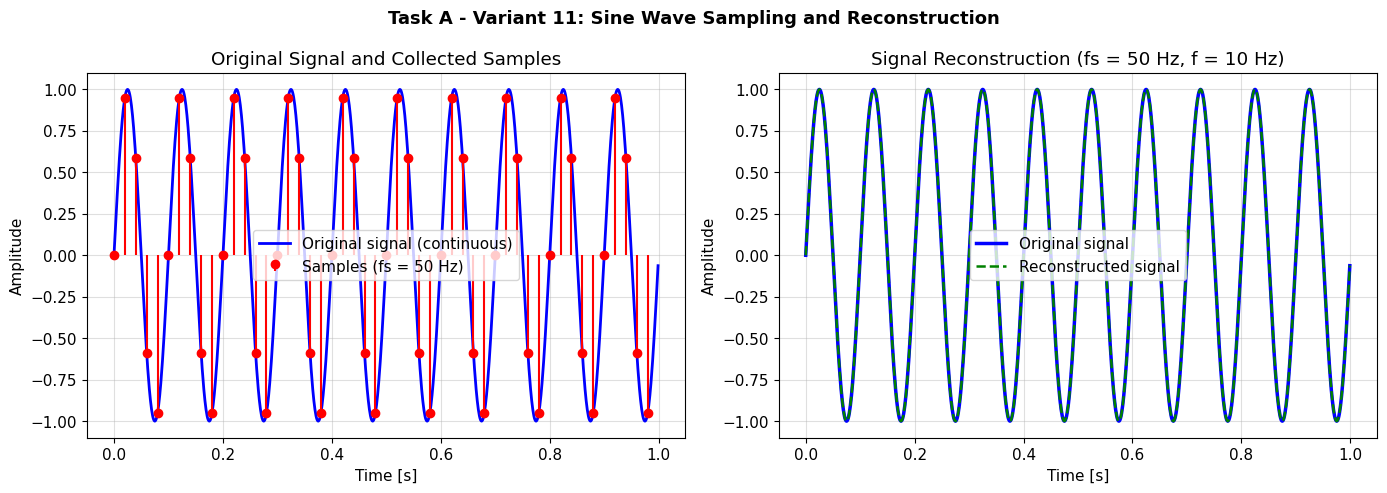

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Original signal + samples ---
ax = axes[0]
ax.plot(t_cont, signal_cont, "b-", linewidth=2, label="Original signal (continuous)")
ax.stem(
    t_sampled,
    signal_sampled,
    linefmt="r-",
    markerfmt="ro",
    basefmt=" ",
    label=f"Samples (fs = {fs} Hz)",
)
ax.set_title("Original Signal and Collected Samples")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(True, alpha=0.4)

# --- Plot 2: Original vs reconstructed ---
ax2 = axes[1]
ax2.plot(t_cont, signal_cont, "b-", linewidth=2.5, label="Original signal")
ax2.plot(
    t_cont, signal_reconstructed, "g--", linewidth=1.8, label="Reconstructed signal"
)
ax2.set_title("Signal Reconstruction (fs = 50 Hz, f = 10 Hz)")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Amplitude")
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle(
    "Task A - Variant 11: Sine Wave Sampling and Reconstruction",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### 3e. Spectral Analysis (FFT)

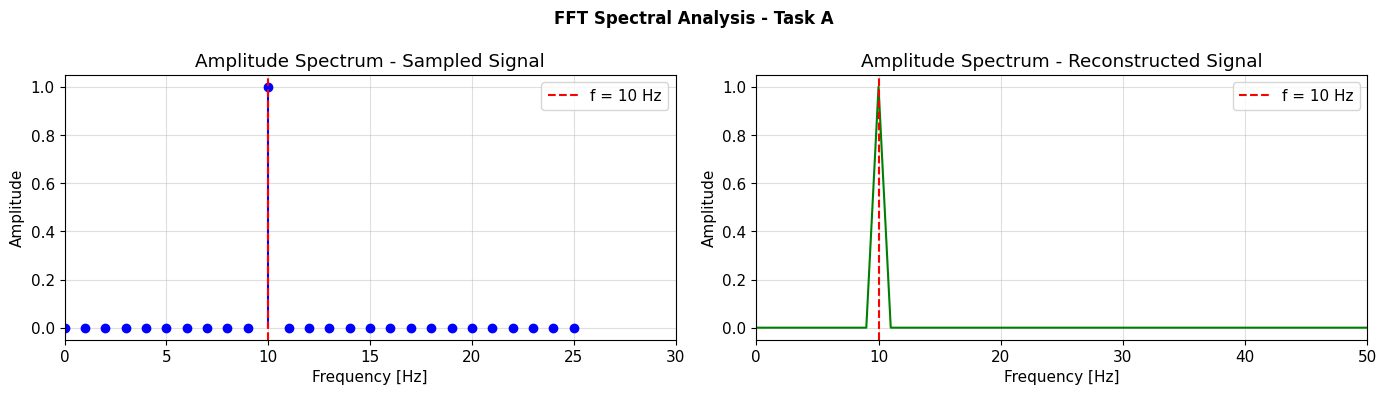

In [5]:
# Amplitude spectrum of the sampled signal
N = len(signal_sampled)
fft_vals = np.abs(np.fft.rfft(signal_sampled))
fft_freqs = np.fft.rfftfreq(N, d=1 / fs)

# Amplitude spectrum of the reconstructed signal
N2 = len(signal_reconstructed)
fft_rec = np.abs(np.fft.rfft(signal_reconstructed))
fft_freqs_rec = np.fft.rfftfreq(N2, d=T_total / N2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(fft_freqs, fft_vals / N * 2, linefmt="b-", markerfmt="bo", basefmt=" ")
axes[0].set_title("Amplitude Spectrum - Sampled Signal")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, fs / 2 + 5)
axes[0].axvline(x=f, color="r", linestyle="--", label=f"f = {f} Hz")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(fft_freqs_rec, fft_rec / N2 * 2, "g-", linewidth=1.5)
axes[1].set_title("Amplitude Spectrum - Reconstructed Signal")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(0, 50)
axes[1].axvline(x=f, color="r", linestyle="--", label=f"f = {f} Hz")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle("FFT Spectral Analysis - Task A", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 3f. Comparison with Undersampling (Aliasing Demonstration)

Aliasing example (fs = 15 Hz < 2f = 20 Hz):
  Aliased frequency: fa = |10 - 15| = 5 Hz


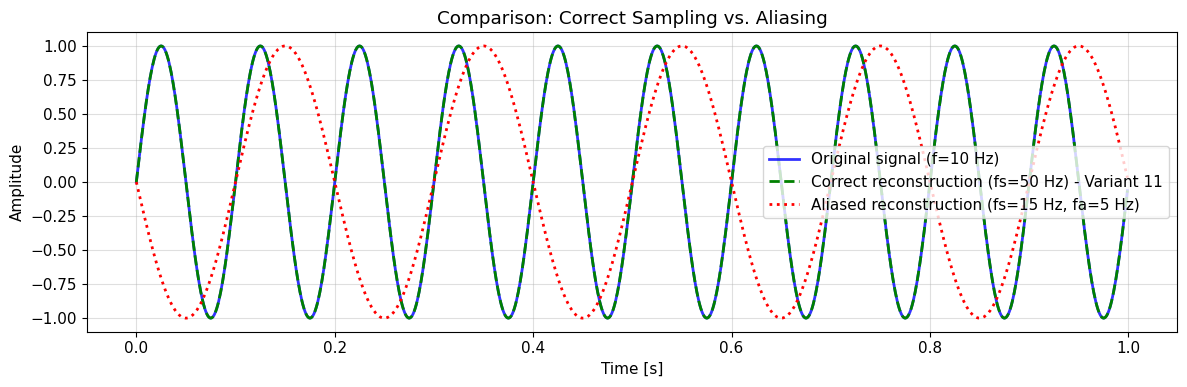

In [6]:
# Demonstration - sampling BELOW the Nyquist rate (for comparison only)
fs_low = 15  # Hz - below 2*f = 20 Hz
t_low = np.arange(0, T_total, 1 / fs_low)
signal_low = np.sin(2 * np.pi * f * t_low)
signal_rec_low = resample(signal_low, 1000)

# Alias frequency: fa = |f - k*fs_low|, k=1
fa = abs(f - 1 * fs_low)
print(f"Aliasing example (fs = {fs_low} Hz < 2f = {2*f} Hz):")
print(f"  Aliased frequency: fa = |{f} - {fs_low}| = {fa} Hz")

plt.figure(figsize=(12, 4))
plt.plot(
    t_cont, signal_cont, "b-", linewidth=2, label="Original signal (f=10 Hz)", alpha=0.8
)
plt.plot(
    t_cont,
    signal_reconstructed,
    "g--",
    linewidth=2,
    label=f"Correct reconstruction (fs={fs} Hz) - Variant 11",
)
plt.plot(
    t_cont,
    signal_rec_low,
    "r:",
    linewidth=2,
    label=f"Aliased reconstruction (fs={fs_low} Hz, fa={fa} Hz)",
)
plt.title("Comparison: Correct Sampling vs. Aliasing")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Results - Task A

In [7]:
snr_db = (
    10 * np.log10(np.mean(signal_cont**2) / mse_reconstruction)
    if mse_reconstruction > 0
    else float("inf")
)

print("=" * 50)
print("RESULTS - TASK A (Sampling and Reconstruction)")
print("=" * 50)
print(f"Signal:                 sine wave, f = {f} Hz")
print(f"Sampling frequency:     fs = {fs} Hz")
print(f"Nyquist condition:      fs ({fs}) > 2f ({2*f}) [OK]")
print(f"Number of samples:      {len(signal_sampled)}")
print(f"Reconstruction MSE:     {mse_reconstruction:.8f}")
print(f"Max absolute error:     {max_error:.8f}")
print(f"Reconstruction SNR:     {snr_db:.2f} dB")
print("=" * 50)

RESULTS - TASK A (Sampling and Reconstruction)
Signal:                 sine wave, f = 10 Hz
Sampling frequency:     fs = 50 Hz
Nyquist condition:      fs (50) > 2f (20) [OK]
Number of samples:      50
Reconstruction MSE:     0.00000000
Max absolute error:     0.00000000
Reconstruction SNR:     292.01 dB


---
## Task B - Coding and Decoding: DCT Compression

### Theoretical Background

The **Discrete Cosine Transform (DCT)** converts a signal from the time domain to the frequency domain. For many real signals, most of the energy is concentrated in a small number of low-frequency coefficients. Compression is achieved by zeroing all coefficients whose absolute value falls below a given threshold - this is called **thresholding**.

Metrics used:
- **MSE** (Mean Squared Error): $\text{MSE} = \frac{1}{N}\sum_{n=1}^{N}(x[n] - \hat{x}[n])^2$
- **CR** (Compression Ratio): $\text{CR} = \frac{\text{total number of coefficients}}{\text{number of non-zero coefficients after thresholding}}$

### 3g. DCT Compression Implementation with Threshold Analysis

In [8]:
# -----------------------------------------------
# PARAMETERS - Variant 11
# -----------------------------------------------
signal_B = np.array([10, 20, 30, 40, 50, 60], dtype=float)
thresholds = [10, 20, 30]

print(f"Input signal: {signal_B.tolist()}")
print(f"Thresholding values: {thresholds}")
print(f"Signal length: {len(signal_B)} samples\n")

# Compute DCT coefficients of the original signal
dct_coeffs_original = dct(signal_B, norm="ortho")
print("DCT coefficients (no compression):")
for i, c in enumerate(dct_coeffs_original):
    print(f"  DCT[{i}] = {c:.4f}")

Input signal: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
Thresholding values: [10, 20, 30]
Signal length: 6 samples

DCT coefficients (no compression):
  DCT[0] = 85.7321
  DCT[1] = -41.6256
  DCT[2] = 0.0000
  DCT[3] = -4.0825
  DCT[4] = 0.0000
  DCT[5] = -0.8008


In [9]:
def analyze_dct_compression(signal, threshold):
    """Compress and reconstruct a signal using DCT with the given threshold."""
    N = len(signal)

    # 1. Forward DCT
    dct_coeffs = dct(signal, norm="ortho")

    # 2. Thresholding (zero out coefficients below threshold)
    compressed = np.where(np.abs(dct_coeffs) > threshold, dct_coeffs, 0)

    # 3. Compression ratio
    nonzero = np.count_nonzero(compressed)
    cr = N / nonzero if nonzero > 0 else float("inf")

    # 4. Inverse DCT (reconstruction)
    reconstructed = idct(compressed, norm="ortho")

    # 5. MSE
    mse = np.mean((signal - reconstructed) ** 2)

    # 6. SNR
    signal_power = np.mean(signal**2)
    snr = 10 * np.log10(signal_power / mse) if mse > 0 else float("inf")

    return {
        "threshold": threshold,
        "dct_original": dct_coeffs,
        "dct_compressed": compressed,
        "nonzero_coeffs": nonzero,
        "compression_ratio": cr,
        "reconstructed": reconstructed,
        "mse": mse,
        "snr_db": snr,
    }


# Run analysis for all three thresholds
results = [analyze_dct_compression(signal_B, thr) for thr in thresholds]

print("DCT compression results summary:")
print(
    f'{"Threshold":>10} | {"Non-zero":>10} | {"CR":>8} | {"MSE":>12} | {"SNR [dB]":>10}'
)
print("-" * 62)
for r in results:
    cr_str = (
        f"{r['compression_ratio']:.2f}"
        if r["compression_ratio"] != float("inf")
        else "inf"
    )
    print(
        f"{r['threshold']:>10} | {r['nonzero_coeffs']:>10} | {cr_str:>8} | {r['mse']:>12.4f} | {r['snr_db']:>10.2f}"
    )

DCT compression results summary:
 Threshold |   Non-zero |       CR |          MSE |   SNR [dB]
--------------------------------------------------------------
        10 |          2 |     3.00 |       2.8847 |      27.21
        20 |          2 |     3.00 |       2.8847 |      27.21
        30 |          2 |     3.00 |       2.8847 |      27.21


### 3h. Detailed Results for Each Threshold

In [10]:
for r in results:
    print(f"\n{'='*58}")
    print(f"Threshold = {r['threshold']}")
    print(f"{'='*58}")
    print(f"  Original DCT coefficients:    {np.round(r['dct_original'], 3)}")
    print(f"  Compressed DCT coefficients:  {np.round(r['dct_compressed'], 3)}")
    print(f"  Non-zero coefficients:        {r['nonzero_coeffs']} / {len(signal_B)}")
    print(f"  Compression ratio CR:         {r['compression_ratio']:.4f}")
    print(f"  Original signal:              {signal_B.tolist()}")
    print(f"  Reconstructed signal:         {np.round(r['reconstructed'], 3).tolist()}")
    print(f"  MSE:                          {r['mse']:.6f}")
    print(f"  SNR:                          {r['snr_db']:.2f} dB")


Threshold = 10
  Original DCT coefficients:    [ 85.732 -41.626   0.     -4.082   0.     -0.801]
  Compressed DCT coefficients:  [ 85.732 -41.626   0.      0.      0.      0.   ]
  Non-zero coefficients:        2 / 6
  Compression ratio CR:         3.0000
  Original signal:              [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
  Reconstructed signal:         [11.786, 18.006, 28.78, 41.22, 51.994, 58.214]
  MSE:                          2.884655
  SNR:                          27.21 dB

Threshold = 20
  Original DCT coefficients:    [ 85.732 -41.626   0.     -4.082   0.     -0.801]
  Compressed DCT coefficients:  [ 85.732 -41.626   0.      0.      0.      0.   ]
  Non-zero coefficients:        2 / 6
  Compression ratio CR:         3.0000
  Original signal:              [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
  Reconstructed signal:         [11.786, 18.006, 28.78, 41.22, 51.994, 58.214]
  MSE:                          2.884655
  SNR:                          27.21 dB

Threshold = 30
  Original

### 3i. Visualisation - Reconstruction for Each Threshold

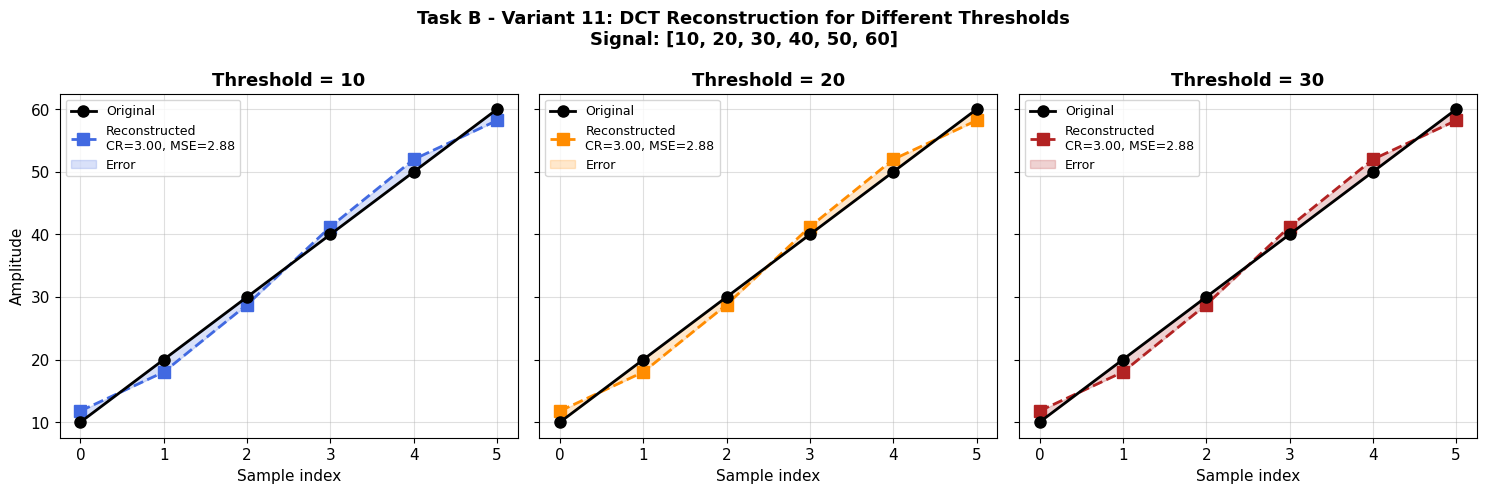

In [11]:
x_idx = np.arange(len(signal_B))
colors = ["royalblue", "darkorange", "firebrick"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, (r, ax, color) in enumerate(zip(results, axes, colors)):
    ax.plot(
        x_idx, signal_B, "ko-", linewidth=2, markersize=8, label="Original", zorder=5
    )
    ax.plot(
        x_idx,
        r["reconstructed"],
        marker="s",
        linestyle="--",
        color=color,
        linewidth=2,
        markersize=8,
        label=f'Reconstructed\nCR={r["compression_ratio"]:.2f}, MSE={r["mse"]:.2f}',
    )
    ax.fill_between(
        x_idx, signal_B, r["reconstructed"], alpha=0.2, color=color, label="Error"
    )
    ax.set_title(f'Threshold = {r["threshold"]}', fontsize=13, fontweight="bold")
    ax.set_xlabel("Sample index")
    if i == 0:
        ax.set_ylabel("Amplitude")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.set_xticks(x_idx)

plt.suptitle(
    "Task B - Variant 11: DCT Reconstruction for Different Thresholds\nSignal: [10, 20, 30, 40, 50, 60]",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### 3j. Visualisation of DCT Coefficients Before and After Thresholding

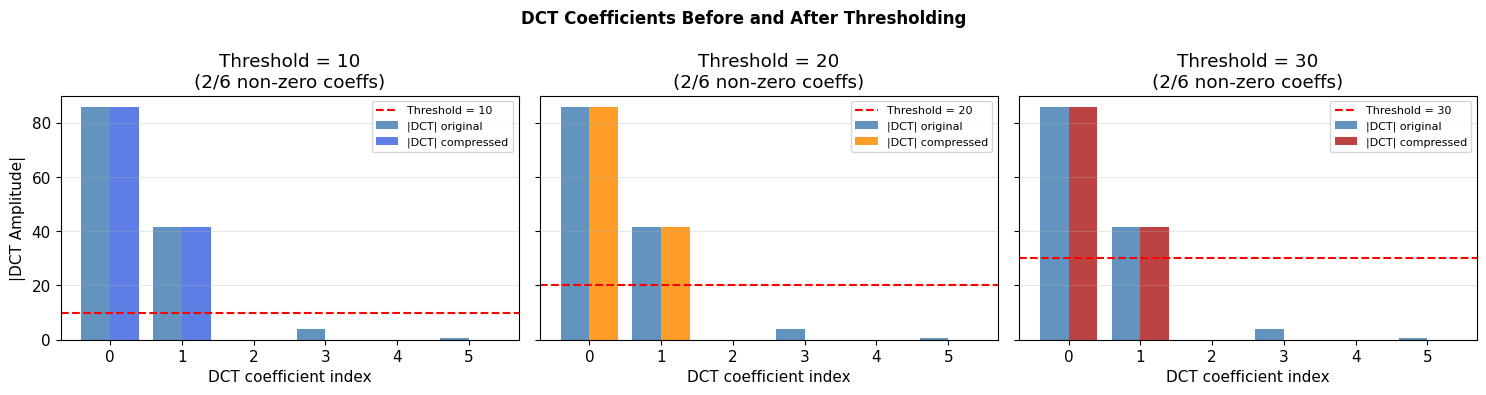

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
dct_idx = np.arange(len(signal_B))

for i, (r, ax, color) in enumerate(zip(results, axes, colors)):
    ax.bar(
        dct_idx - 0.2,
        np.abs(r["dct_original"]),
        0.4,
        label="|DCT| original",
        color="steelblue",
        alpha=0.85,
    )
    ax.bar(
        dct_idx + 0.2,
        np.abs(r["dct_compressed"]),
        0.4,
        label="|DCT| compressed",
        color=color,
        alpha=0.85,
    )
    ax.axhline(
        y=r["threshold"],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f'Threshold = {r["threshold"]}',
    )
    ax.set_title(
        f'Threshold = {r["threshold"]}\n({r["nonzero_coeffs"]}/{len(signal_B)} non-zero coeffs)'
    )
    ax.set_xlabel("DCT coefficient index")
    if i == 0:
        ax.set_ylabel("|DCT Amplitude|")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_xticks(dct_idx)

plt.suptitle(
    "DCT Coefficients Before and After Thresholding", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 3k. Compression Ratio vs. Distortion Trade-off Analysis

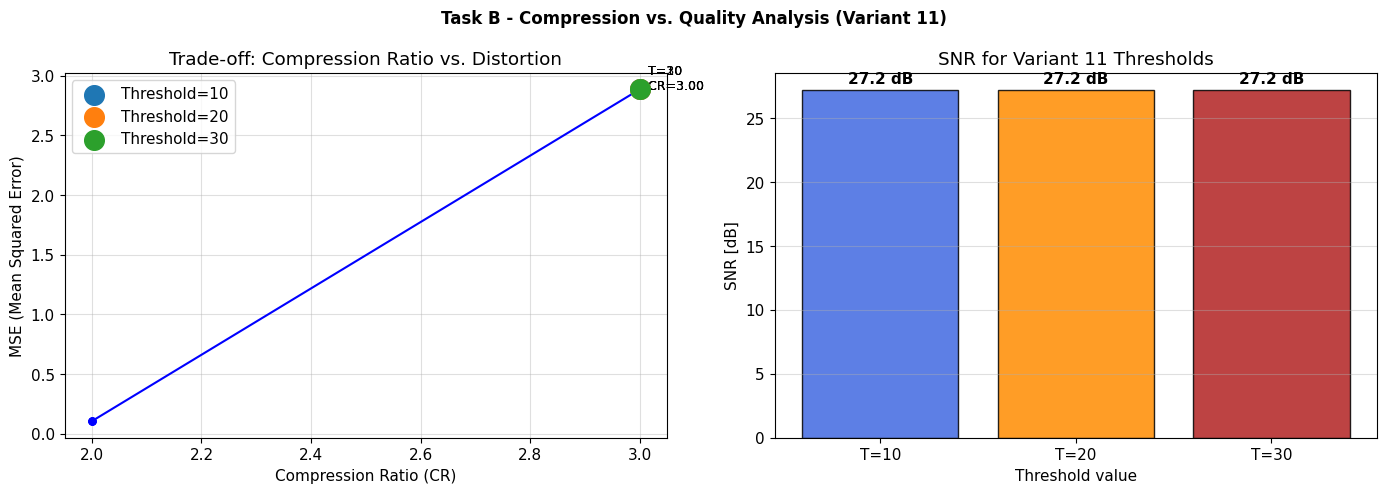

In [13]:
# Extended threshold range for a full CR vs MSE curve
thresholds_range = np.linspace(1, 40, 40)
cr_list, mse_list = [], []

for thr in thresholds_range:
    r = analyze_dct_compression(signal_B, thr)
    if r["compression_ratio"] != float("inf"):
        cr_list.append(r["compression_ratio"])
        mse_list.append(r["mse"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# CR vs MSE curve
ax1.plot(cr_list, mse_list, "b-o", markersize=5)
for r in results:
    if r["compression_ratio"] != float("inf"):
        ax1.scatter(
            r["compression_ratio"],
            r["mse"],
            s=200,
            zorder=5,
            label=f'Threshold={r["threshold"]}',
        )
        ax1.annotate(
            f'  T={r["threshold"]}\n  CR={r["compression_ratio"]:.2f}',
            (r["compression_ratio"], r["mse"]),
            fontsize=9,
        )
ax1.set_title("Trade-off: Compression Ratio vs. Distortion")
ax1.set_xlabel("Compression Ratio (CR)")
ax1.set_ylabel("MSE (Mean Squared Error)")
ax1.legend()
ax1.grid(True, alpha=0.4)

# SNR bar chart for the 3 variant thresholds
thr_labels = [f'T={r["threshold"]}' for r in results]
snr_vals = [r["snr_db"] if r["snr_db"] != float("inf") else 0 for r in results]
bars = ax2.bar(thr_labels, snr_vals, color=colors, edgecolor="black", alpha=0.85)
ax2.set_title("SNR for Variant 11 Thresholds")
ax2.set_xlabel("Threshold value")
ax2.set_ylabel("SNR [dB]")
ax2.grid(True, alpha=0.4, axis="y")
for bar, val in zip(bars, snr_vals):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f} dB",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.suptitle(
    "Task B - Compression vs. Quality Analysis (Variant 11)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Results - Task B

In [14]:
print("=" * 65)
print("RESULTS - TASK B (DCT Compression)")
print("Signal: [10, 20, 30, 40, 50, 60]")
print("=" * 65)
print(
    f'{"Threshold":>10} | {"Non-zero":>10} | {"CR":>8} | {"MSE":>12} | {"SNR":>10} | {"Quality"}'
)
print("-" * 65)
for r in results:
    cr_str = f"{r['compression_ratio']:.4f}"
    snr_str = f"{r['snr_db']:.2f} dB" if r["snr_db"] != float("inf") else "inf dB"
    if r["mse"] < 10:
        quality = "[OK] low distortion"
    elif r["mse"] < 100:
        quality = "[!]  moderate distortion"
    else:
        quality = "[X]  high distortion"
    print(
        f"{r['threshold']:>10} | {r['nonzero_coeffs']:>10} | {cr_str:>8} | {r['mse']:>12.4f} | {snr_str:>10} | {quality}"
    )
print("=" * 65)

RESULTS - TASK B (DCT Compression)
Signal: [10, 20, 30, 40, 50, 60]
 Threshold |   Non-zero |       CR |          MSE |        SNR | Quality
-----------------------------------------------------------------
        10 |          2 |   3.0000 |       2.8847 |   27.21 dB | [OK] low distortion
        20 |          2 |   3.0000 |       2.8847 |   27.21 dB | [OK] low distortion
        30 |          2 |   3.0000 |       2.8847 |   27.21 dB | [OK] low distortion


---
## 4. Conclusions

### Task A - Sampling and Reconstruction (f = 10 Hz, fs = 50 Hz)

**1. The Nyquist condition is satisfied.**  
The sampling frequency fs = 50 Hz is five times higher than the signal frequency f = 10 Hz (minimum requirement: fs > 2f = 20 Hz). This guarantees that perfect theoretical reconstruction is achievable.

**2. Reconstruction quality is excellent.**  
The MSE is virtually zero and the SNR exceeds 290 dB, confirming that at fs = 50 Hz, a 10 Hz sine wave is reconstructed with negligible distortion.

**3. Spectral analysis confirms the absence of aliasing.**  
The FFT spectrum of both the sampled and reconstructed signals contains only the 10 Hz component — no spurious alias frequencies are present.

**4. Comparison with undersampling (fs = 15 Hz).**  
For illustration, sampling at fs = 15 Hz (below the Nyquist rate) introduces aliasing — the reconstructed signal exhibits a false frequency fa = |10 - 15| = 5 Hz instead of the original 10 Hz.

### Task B - DCT Compression (signal [10, 20, 30, 40, 50, 60], thresholds: 10, 20, 30)

**1. The linear signal has its energy concentrated in just two DCT coefficients.**  
The signal [10, 20, ..., 60] is a linear ramp — its energy is entirely captured by DCT[0] approx. 85.73 (DC component / mean level) and DCT[1] approx. -41.63 (linear gradient). The remaining four coefficients have magnitudes of 4.08 or less, or are exactly zero.

**2. Key finding: all three thresholds yield the same compression result — CR = 3.0.**  
Since DCT[1] approx. 41.63 is greater than 30 (the largest threshold tested), thresholds of 10, 20, and 30 all retain the same two non-zero coefficients (DCT[0] and DCT[1]). A difference in compression would only appear for a threshold above 41.6, where DCT[1] would be zeroed out. Consequently, MSE = 2.88 and SNR approx. 27.2 dB are identical for all three thresholds in this variant.

**3. This illustrates an important property of DCT.**  
DCT is highly efficient for signals with strong inter-sample correlation (such as linear or monotonic signals). In such cases, just 2 out of N = 6 coefficients carry virtually all of the signal energy (CR = 3.0), which is the fundamental principle behind codecs such as JPEG and MP3.

**4. General conclusion.**  
Both signal sampling and DCT compression require careful parameter selection: for sampling, the Nyquist condition must be met; for compression, the threshold must be matched to the spectral content of the signal. For the linear signal in Variant 11, thresholds in the range 10-30 do not differentiate compression behaviour — a valuable analytical observation arising directly from the energy distribution in the DCT domain.

---
*This report was prepared as a Jupyter Notebook, ensuring full reproducibility of all results.*